# 로지스틱 회귀(Logistic Regression)

분류에 사용되는 ML 모델

## 시그모이드 함수를 사용
학습을 통해서 구해지는 예측값을 0-1 사이의 확률값으로 변경해주는 함수

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 200

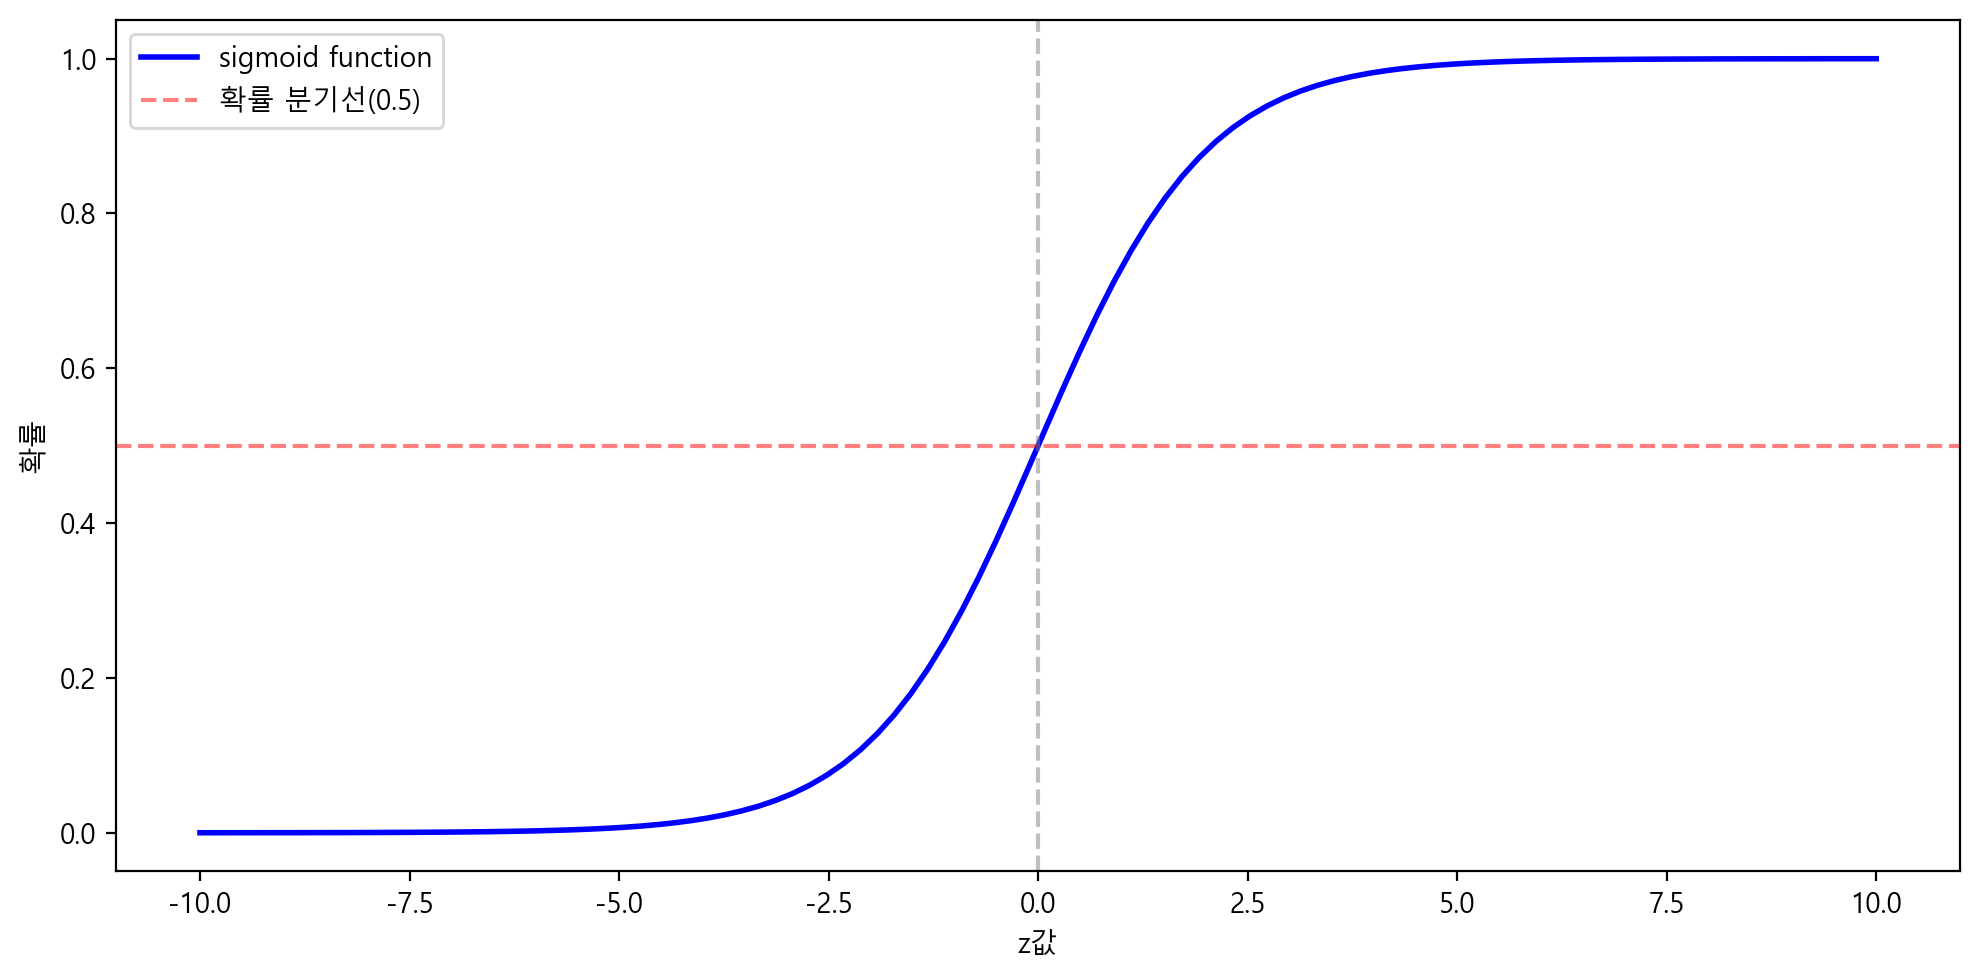

In [2]:

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


z = np.linspace(-10, 10, 100)
result = sigmoid(z)

plt.figure(figsize=(10, 5))
plt.plot(z, result, color='blue', linewidth=2, label='sigmoid function')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='확률 분기선(0.5)')

plt.xlabel('z값')
plt.ylabel('확률')
plt.tight_layout()
plt.legend()
plt.show()

In [3]:
df = pd.read_csv('data/train_and_test2.csv')
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [4]:
cols = df.columns[df.columns.str.contains('zero', case=False, na=False)]

df = df.drop(columns=['Passengerid'] + list(cols), errors='ignore')

df.head()

,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,2urvived
0,22.0,7.2500,0,1,0,3,2.0,0
1,38.0,71.2833,1,1,0,1,0.0,1
2,26.0,7.9250,1,0,0,3,2.0,1
3,35.0,53.1000,1,1,0,1,2.0,1
4,35.0,8.0500,0,0,0,3,2.0,0


In [5]:
df = df.rename(columns={'2urvived' : 'Survived'})
df.head(3)

,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,22.0,7.2500,0,1,0,3,2.0,0
1,38.0,71.2833,1,1,0,1,0.0,1
2,26.0,7.9250,1,0,0,3,2.0,1


In [6]:
df['Embarked'].nunique

<bound method IndexOpsMixin.nunique of 0       2.0
1       0.0
2       2.0
3       2.0
4       2.0
       ... 
1304    2.0
1305    0.0
1306    2.0
1307    2.0
1308    0.0
Name: Embarked, Length: 1309, dtype: float64>

In [7]:
# 결측치 삭제하기
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1307 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       1307 non-null   float64
 1   Fare      1307 non-null   float64
 2   Sex       1307 non-null   int64  
 3   sibsp     1307 non-null   int64  
 4   Parch     1307 non-null   int64  
 5   Pclass    1307 non-null   int64  
 6   Embarked  1307 non-null   float64
 7   Survived  1307 non-null   int64  
dtypes: float64(3), int64(5)
memory usage: 91.9 KB


In [8]:
X = df.drop(columns='Survived', axis=1)
y = df['Survived']

print(X.shape)
print(y.shape)

(1307, 7)
(1307,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1045, 7)
(262, 7)
(1045,)
(262,)


## 스케일링 적용여부 설정하기

|모델|스케일링|이유|
|---|---|---|
|선형회귀|선택적|예측값은 안변함, 계수(coef)값을 비교하려면 권장|
|로지스틱회귀|권장|sklearn에 의해 권장되고 있음|
|Decesion Tree|불필요||
|Random Forest|불필요||
|Gradient Boost|불필요||
|Deep Learning|필수|여러 변수들을 표준화하여 지속적으로 연산을 수행함|

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()   # 평균이 0, 표준편차가 1인 값들로 스케일링

X_train_s = scaler.fit_transform(X_train)   # 학습(다른 컬럼들과의 관계식)과 변환 둘 다 해줌
X_test_s = scaler.transform(X_test)         # 변환만 해줌

# 로지스틱 회귀 모델 생성과 학습
logiReg = LogisticRegression(random_state=42)
model = logiReg.fit(X_train_s, y_train)

# 예측하기
y_pred = model.predict(X_test_s)

s_coef = pd.Series(model.coef_[0], index=X_train.columns).sort_values(key=abs, ascending=False)
s_coef

Sex         0.875054
Pclass     -0.632251
Age        -0.363765
sibsp      -0.140624
Parch      -0.037494
Embarked   -0.028073
Fare        0.001856
dtype: float64

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

acc_score = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc_score}')

Accuracy: 0.7900763358778626


In [ ]:
print(classification_report(y_test, y_pred))

# precision: 생존(사망)이라 예측한 사람 중 진짜 생존(사망)은 몇 %인가
# recall: 실제 생존(사망)자 중 몇 명을 찾아냈는가?
# f1-score: pr 과 re를 조합하여 최종 점수를 책정함
# support: 샘플 수

              precision    recall  f1-score   support

           0       0.80      0.95      0.87       192
           1       0.73      0.34      0.47        70

    accuracy                           0.79       262
   macro avg       0.76      0.65      0.67       262
weighted avg       0.78      0.79      0.76       262



In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[183   9]
 [ 46  24]]


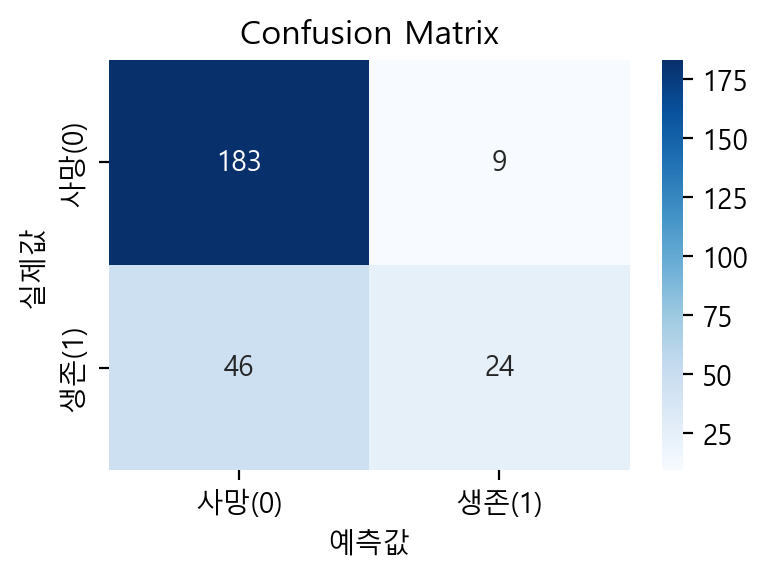

In [15]:
# Visualization via heatmap
plt.figure(figsize=(4, 3))


sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=['사망(0)', '생존(1)'], yticklabels=['사망(0)', '생존(1)'])

plt.xlabel('예측값')
plt.ylabel('실제값')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()